# `Polygon2d` from a simple Voronoi tessellation

A grain structure that never touched a pixel grid at all: `pxtal.vortess2d.gtess2d`
builds a Voronoi tessellation directly from seed points and hands back a Shapely
`MultiPolygon`. `polygon_collection_from_shapely` converts that straight into a
topologically-linked `{gid: Polygon2d}` -- the converter doesn't care whether its
input came from Technique B, a Voronoi engine, or anywhere else that produces
neighbouring Shapely polygons.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from shapely.geometry import MultiPolygon

from upxo.pxtal.vortess2d import gtess2d
from upxo.geoEntities.polygon2d_from_shapely import polygon_collection_from_shapely
from upxo.viz import gsviz

def find_shared_segment(poly_a, poly_b):
    for ia, sa in enumerate(poly_a.ring.segments):
        for ib, sb in enumerate(poly_b.ring.segments):
            if sa is sb:
                return ia, ib, sa
    return None

## 1. Build the Voronoi tessellation and convert

`sp_input='load'` takes an explicit `(n, 2)` seed array -- a predictable grain count for
a demo, rather than density-controlled Poisson-disk sampling.

12 Voronoi cells, total area 2000.0767
polygon_collection_from_shapely: normalising input parts
  12 loop(s) across 12 grain(s)
  22 junction point(s) detected
gbsegs continuous
gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continuous. N.Segs=3. N.Iterations=4
gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continuous. N.Segs=6. N.Iterations=7
gbsegs continuous
gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continuous. N.Segs=4. N.Iterations=5
gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continuous. N.Segs=7. N.Iterations=8
gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continuous. N.Segs=7. N.Iterations=8
gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continuous. N.Segs=4. N.Iterations=5
gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continuous. N.Segs=5. N.Iterations=6
gbsegs continuous
gb

Text(0.5, 1.0, 'Voronoi tessellation -> Polygon2d')

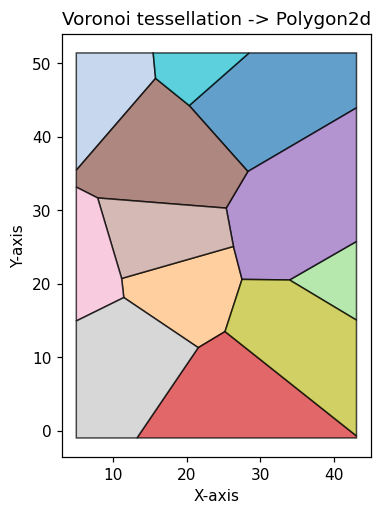

In [2]:
rng = np.random.default_rng(seed=1)
seeds = rng.uniform(0, 50, size=(12, 2))
tess = gtess2d.from_seed_points(sp_input='load', sp_in=seeds, xbound=[0, 50], ybound=[0, 50])
mpoly = tess.pxtals[1]
cells = {i: poly for i, poly in enumerate(mpoly.geoms, start=1)}
print(f"{len(cells)} Voronoi cells, total area {mpoly.area:.4f}")

result = polygon_collection_from_shapely(cells, verbose=True)
print(f"\narea check: sum(cells)={sum(c.area for c in cells.values()):.4f}, "
     f"sum(result)={sum(p.area for p in result.values()):.4f}")

fig, ax = plt.subplots(figsize=(5, 5), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in result.values()]), fig=fig, ax=ax)
ax.set_title('Voronoi tessellation -> Polygon2d')

## 2. Edit a shared wall

Find any neighbouring pair, bulge the shared wall via one grain only, confirm the other
follows exactly and total area is conserved.

grain 1: 238.4573 -> 249.8859
grain 6: 284.8619 -> 273.4333
total area: 2000.0767 -> 2000.0767  (conserved: True)
neighbour matches exactly, no gap: True


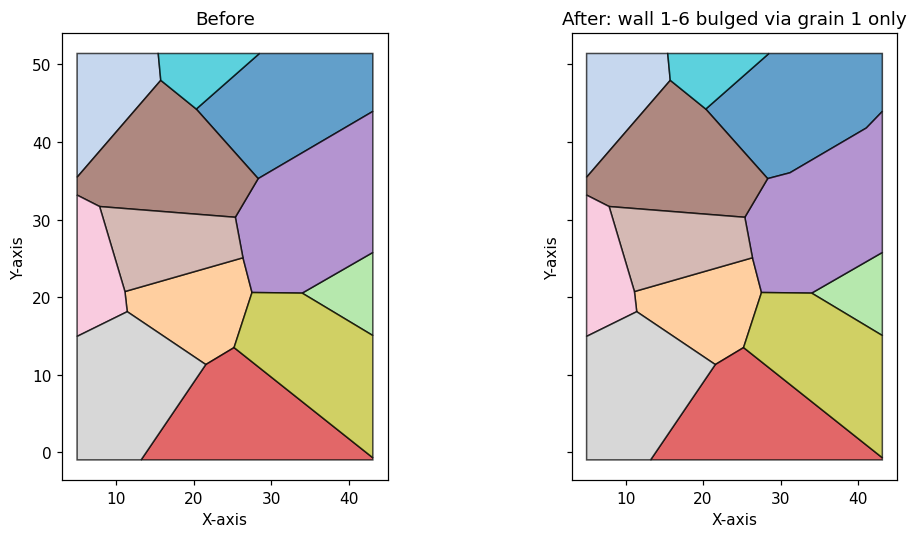

In [3]:
gids = list(result.keys())
match = None
for i, ga in enumerate(gids):
    for gb in gids[i + 1:]:
        m = find_shared_segment(result[ga], result[gb])
        if m is not None:
            match = (ga, gb, *m)
            break
    if match:
        break

ga, gb, ia, ib, shared = match
pa, pb = result[ga], result[gb]
area_before = {g: p.area for g, p in result.items()}
total_before = sum(area_before.values())

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=110, sharex=True, sharey=True)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in result.values()]), fig=fig, ax=axes[0])
axes[0].set_title('Before')

pa.subdivide_segment(ia, n=5)
coords = pa.ring.segments[ia].get_node_coords()
tangent = coords[-1] - coords[0]
normal = np.array([-tangent[1], tangent[0]])
normal = normal / np.linalg.norm(normal)
new_coords = coords.copy()
for k in range(1, len(coords) - 1):
    new_coords[k] = new_coords[k] + 0.8 * normal
pa.edit_segment(ia, new_coords)

gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in result.values()]), fig=fig, ax=axes[1])
axes[1].set_title(f'After: wall {ga}-{gb} bulged via grain {ga} only')
fig.tight_layout()

no_gap = np.array_equal(pa.ring.segments[ia].get_node_coords(), pb.ring.segments[ib].get_node_coords())
total_after = sum(p.area for p in result.values())
print(f"grain {ga}: {area_before[ga]:.4f} -> {pa.area:.4f}")
print(f"grain {gb}: {area_before[gb]:.4f} -> {pb.area:.4f}")
print(f"total area: {total_before:.4f} -> {total_after:.4f}  (conserved: {np.isclose(total_before, total_after)})")
print(f"neighbour matches exactly, no gap: {no_gap}")